# E1 — Behavioral revision curve

**Plan reference:** Phase 1, experiment E1.

**Question:** How does revision success vary with where the revision cue is inserted?

**This is not interpretability.** Final next-token behavior only — no logit lens, no tuned lens.
Any later structural measure (E2+) has to beat this baseline: *token-index / cue placement alone*.

---

## What "depth" means here (design A)

We keep the forced-error skeleton from E0:

```text
{a} + {b} = {W}.{FILLER}{CUE} {a} + {b} =
```

**Depth = cue lag:** how many filler tokens sit between the wrong answer `W` and the revision cue.
Lag 0 is the E0-style prompt (cue immediately after `W.`). Larger lag = cue appears later in the sequence.

We are **not** yet varying how long a wrong reasoning trajectory the model generates before any cue
(that would be design B). Ask if that distinction is unclear.

## Metrics (at final `=`)

| Metric | Meaning |
|---|---|
| `score` | $\mathrm{logit}(W) - \mathrm{logit}(C)$ — positive means still prefers wrong |
| `top1_is_C` | next-token argmax is the correct answer token |
| `top1_is_W` | next-token argmax is the wrong answer token |

## Control

Length-matched **no-cue**: same total token length, but the cue span is replaced by filler tokens.
If the cue does work, cue curves should look different from no-cue curves.

In [1]:
# --- Install (uncomment on a fresh environment) ---------------------------------
# %pip install transformer-lens torch matplotlib numpy pandas

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import transformer_lens as tl
from dataclasses import dataclass

torch.set_grad_enabled(False)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cpu


## 1. Load model

Final-logit scoring only — `fold_ln` does not matter here. Default TransformerLens load is fine.

In [2]:
model = tl.HookedTransformer.from_pretrained("gpt2", device=DEVICE)
model.eval()
print(f"layers={model.cfg.n_layers}  d_model={model.cfg.d_model}  device={model.cfg.device}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer
layers=12  d_model=768  device=cpu


## 2. Prompt bank + builders

Each item needs `W` and `C` as **single** GPT-2 tokens (leading space included, as in E0).
We discover a single-token filler unit at runtime and repeat it for controlled lag / no-cue padding.

In [3]:
@dataclass(frozen=True)
class Item:
    name: str
    a: int
    b: int
    W_str: str   # wrong answer token string, e.g. " 25"
    C_str: str   # correct answer token string, e.g. " 27"


ITEMS = [
    Item("ops_12+15", 12, 15, " 25", " 27"),
    Item("ops_8+7", 8, 7, " 14", " 15"),
    Item("ops_11+12", 11, 12, " 22", " 23"),
    Item("ops_9+6", 9, 6, " 14", " 15"),
    Item("ops_13+14", 13, 14, " 26", " 27"),
    Item("ops_4+5", 4, 5, " 8", " 9"),
    Item("ops_16+10", 16, 10, " 24", " 26"),
    Item("ops_3+8", 3, 8, " 10", " 11"),
]

CUES = {
    "wait_recompute": " Wait, let me recompute.",
    "actually": " Actually, let me recalculate.",
    "hold_on": " Hold on, let me try again.",
}

# Cue lags to sweep (tokens between "W." and the cue). Lag 0 = E0-style adjacency.
LAGS = list(range(0, 9))  # 0..8


def assert_single_token(s: str, label: str) -> int:
    """GPT-2 single content token (to_str_tokens includes BOS, so length == 2)."""
    tid = model.to_single_token(s)
    toks = model.to_str_tokens(s)
    assert len(toks) == 2 and toks[1] == s, (
        f"{label}={s!r} not a clean single token: {toks!r}"
    )
    return tid


for it in ITEMS:
    assert_single_token(it.W_str, f"{it.name}.W")
    assert_single_token(it.C_str, f"{it.name}.C")
print(f"checked {len(ITEMS)} items: W/C are single tokens")

# Find a single-token filler we can repeat for lag / length matching.
# to_str_tokens includes BOS → a single content token has length 2.
FILLER_CANDIDATES = [" ...", " uh", " and", " then", " so", " ."]
FILLER_UNIT = None
for cand in FILLER_CANDIDATES:
    toks = model.to_str_tokens(cand)
    if len(toks) == 2:
        FILLER_UNIT = cand
        break
if FILLER_UNIT is None:
    raise RuntimeError(f"No single-token filler in {FILLER_CANDIDATES}")
print(f"filler unit: {FILLER_UNIT!r}  -> {model.to_str_tokens(FILLER_UNIT)}")


def n_tokens(text: str) -> int:
    # Exclude BOS so string-concat length accounting matches content tokens.
    return len(model.to_str_tokens(text)) - 1


def filler_span(n: int) -> str:
    if n <= 0:
        return ""
    return FILLER_UNIT * n


def build_prompt(item: Item, cue_key: str | None, lag: int) -> str:
    """Forced-error prompt with optional cue at given lag after W.

    cue_key=None → no-cue control. Length is matched to the same lag with the default
    cue "wait_recompute" (filler replaces the cue tokens).
    """
    prefix = f"{item.a} + {item.b} ={item.W_str}."
    suffix = f" {item.a} + {item.b} ="
    mid_lag = filler_span(lag)

    if cue_key is None:
        # Match length of wait_recompute cue at this lag
        cue_len = n_tokens(CUES["wait_recompute"])
        middle = mid_lag + filler_span(cue_len)
    else:
        middle = mid_lag + CUES[cue_key]

    return prefix + middle + suffix


# Sanity: show one tokenization
demo = build_prompt(ITEMS[0], "wait_recompute", lag=2)
print("\nDemo prompt:", repr(demo))
print("tokens:")
for i, t in enumerate(model.to_str_tokens(demo)):
    print(f"  {i:2d}  {t!r}")

ctrl = build_prompt(ITEMS[0], None, lag=2)
print("\nNo-cue control:", repr(ctrl))
print(
    "token lengths cue/control:",
    n_tokens(demo),
    n_tokens(ctrl),
)
assert n_tokens(demo) == n_tokens(ctrl), "length-matched control failed"

checked 8 items: W/C are single tokens
filler unit: ' ...'  -> ['<|endoftext|>', ' ...']

Demo prompt: '12 + 15 = 25. ... ... Wait, let me recompute. 12 + 15 ='
tokens:
   0  '<|endoftext|>'
   1  '12'
   2  ' +'
   3  ' 15'
   4  ' ='
   5  ' 25'
   6  '.'
   7  ' ...'
   8  ' ...'
   9  ' Wait'
  10  ','
  11  ' let'
  12  ' me'
  13  ' recomp'
  14  'ute'
  15  '.'
  16  ' 12'
  17  ' +'
  18  ' 15'
  19  ' ='

No-cue control: '12 + 15 = 25. ... ... ... ... ... ... ... ... ... 12 + 15 ='
token lengths cue/control: 19 19


## 3. Scoring helper

Run the full prompt; read next-token logits at the final `=` (`t*`).

In [4]:
def score_prompt(prompt: str, W_str: str, C_str: str) -> dict:
    """Score next-token preference at final '='.

    TransformerLens `to_tokens` / `to_str_tokens` both include BOS at index 0,
    so str-token indices align directly with logit positions.
    """
    W_id = model.to_single_token(W_str)
    C_id = model.to_single_token(C_str)
    tokens = model.to_tokens(prompt)  # [1, seq] with BOS
    str_toks = model.to_str_tokens(prompt)
    assert tokens.shape[1] == len(str_toks)

    eq_pos = [i for i, t in enumerate(str_toks) if t == " ="]
    if not eq_pos:
        raise ValueError(f"No ' =' token in prompt: {prompt!r}")
    t_star = eq_pos[-1]

    logits = model(tokens)  # [1, seq, d_vocab]
    logit_vec = logits[0, t_star]

    score = float(logit_vec[W_id] - logit_vec[C_id])
    top_id = int(logit_vec.argmax())
    top_str = model.to_string([top_id])
    return {
        "prompt": prompt,
        "n_tokens": len(str_toks) - 1,  # content tokens only
        "t_star": t_star,
        "score": score,
        "top1": top_str,
        "top1_is_W": top_id == W_id,
        "top1_is_C": top_id == C_id,
        "logit_W": float(logit_vec[W_id]),
        "logit_C": float(logit_vec[C_id]),
    }


# Smoke test on E0-style lag-0 cue (expect score ≈ +4.2, top1 ≈ ' 25' from prior check)
smoke = score_prompt(build_prompt(ITEMS[0], "wait_recompute", 0), ITEMS[0].W_str, ITEMS[0].C_str)
for k, v in smoke.items():
    if k != "prompt":
        print(f"{k}: {v}")
print("prompt:", smoke["prompt"])
assert smoke["top1_is_W"] or smoke["score"] > 0, "unexpected: lag-0 baseline should prefer W"

n_tokens: 17
t_star: 17
score: 4.194225311279297
top1:  25
top1_is_W: True
top1_is_C: False
logit_W: 17.344602584838867
logit_C: 13.15037727355957
prompt: 12 + 15 = 25. Wait, let me recompute. 12 + 15 =


## 4. Sweep — items × cues × lags (+ no-cue controls)

Pre-registered null (soft): a flat cue curve that matches the no-cue control means cue placement
/ lag alone does not drive revision success for this family.

In [5]:
rows = []

conditions = [(f"cue:{k}", k) for k in CUES] + [("no_cue", None)]
total = len(ITEMS) * len(conditions) * len(LAGS)
done = 0

for item in ITEMS:
    for cond_name, cue_key in conditions:
        for lag in LAGS:
            prompt = build_prompt(item, cue_key, lag)
            out = score_prompt(prompt, item.W_str, item.C_str)
            rows.append(
                {
                    "item": item.name,
                    "a": item.a,
                    "b": item.b,
                    "W": item.W_str,
                    "C": item.C_str,
                    "condition": cond_name,
                    "cue": cue_key if cue_key is not None else "none",
                    "lag": lag,
                    **{k: out[k] for k in (
                        "n_tokens", "t_star", "score", "top1",
                        "top1_is_W", "top1_is_C", "logit_W", "logit_C",
                    )},
                }
            )
            done += 1
            if done % 48 == 0 or done == total:
                print(f"{done}/{total}")

df = pd.DataFrame(rows)
print(df.shape)
df.head(12)

48/288
96/288
144/288
192/288
240/288
288/288
(288, 16)


,item,a,b,W,C,condition,cue,lag,n_tokens,t_star,score,top1,top1_is_W,top1_is_C,logit_W,logit_C
0,ops_12+15,12,15,25,27,cue:wait_recompute,wait_recompute,0,17,17,4.194225,25,True,False,17.344603,13.150377
1,ops_12+15,12,15,25,27,cue:wait_recompute,wait_recompute,1,18,18,4.112602,25,True,False,17.333223,13.220621
2,ops_12+15,12,15,25,27,cue:wait_recompute,wait_recompute,2,19,19,4.014603,25,True,False,17.415386,13.400784
3,ops_12+15,12,15,25,27,cue:wait_recompute,wait_recompute,3,20,20,3.936746,25,True,False,17.504679,13.567933
4,ops_12+15,12,15,25,27,cue:wait_recompute,wait_recompute,4,21,21,3.898536,25,True,False,17.595665,13.697129
5,ops_12+15,12,15,25,27,cue:wait_recompute,wait_recompute,5,22,22,3.852382,25,True,False,17.679514,13.827132
6,ops_12+15,12,15,25,27,cue:wait_recompute,wait_recompute,6,23,23,3.812638,25,True,False,17.734535,13.921897
7,ops_12+15,12,15,25,27,cue:wait_recompute,wait_recompute,7,24,24,3.766588,25,True,False,17.805696,14.039108
8,ops_12+15,12,15,25,27,cue:wait_recompute,wait_recompute,8,25,25,3.743114,25,True,False,17.856873,14.113758
9,ops_12+15,12,15,25,27,cue:actually,actually,0,18,18,3.942133,25,True,False,17.231308,13.289175


## 5. Aggregate curves

In [6]:
agg = (
    df.groupby(["condition", "lag"], as_index=False)
    .agg(
        mean_score=("score", "mean"),
        std_score=("score", "std"),
        frac_top1_C=("top1_is_C", "mean"),
        frac_top1_W=("top1_is_W", "mean"),
        n=("score", "size"),
    )
)
agg

,condition,lag,mean_score,std_score,frac_top1_C,frac_top1_W,n
0,cue:actually,0,2.776949,0.993966,0.000,1.000,8
1,cue:actually,1,2.727083,1.016863,0.000,1.000,8
2,cue:actually,2,2.659462,1.027936,0.000,1.000,8
3,cue:actually,3,2.662359,1.045483,0.000,1.000,8
4,cue:actually,4,2.678545,1.054843,0.000,1.000,8
5,cue:actually,5,2.687154,1.061786,0.000,1.000,8
6,cue:actually,6,2.678072,1.071182,0.000,1.000,8
7,cue:actually,7,2.691573,1.073001,0.000,1.000,8
8,cue:actually,8,2.684411,1.077141,0.000,1.000,8
9,cue:hold_on,0,2.377568,1.031662,0.000,1.000,8


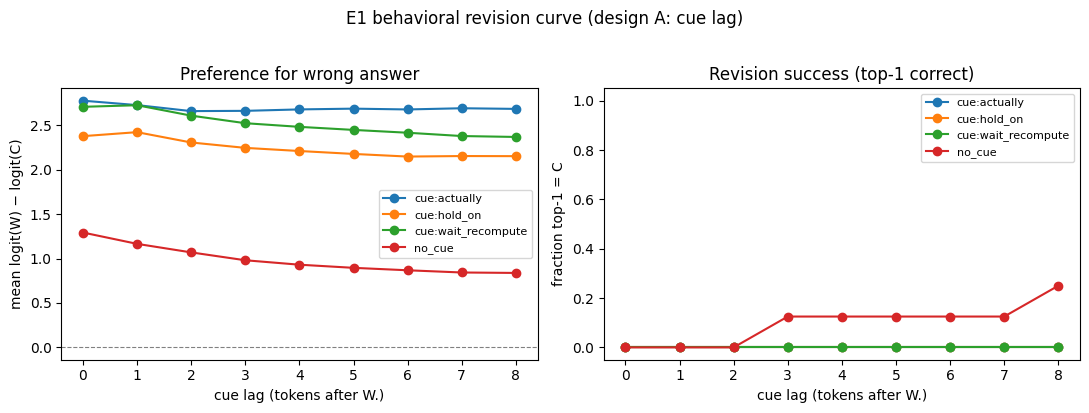

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

for cond, g in agg.groupby("condition"):
    g = g.sort_values("lag")
    axes[0].plot(g["lag"], g["mean_score"], marker="o", label=cond)
    axes[1].plot(g["lag"], g["frac_top1_C"], marker="o", label=cond)

axes[0].axhline(0.0, color="gray", lw=0.8, ls="--")
axes[0].set_xlabel("cue lag (tokens after W.)")
axes[0].set_ylabel("mean logit(W) − logit(C)")
axes[0].set_title("Preference for wrong answer")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("cue lag (tokens after W.)")
axes[1].set_ylabel("fraction top-1 = C")
axes[1].set_title("Revision success (top-1 correct)")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(fontsize=8)

fig.suptitle("E1 behavioral revision curve (design A: cue lag)", y=1.02)
fig.tight_layout()
plt.show()

## 6. Per-item breakdown

Check whether any aggregate effect is driven by one lucky operand pair.

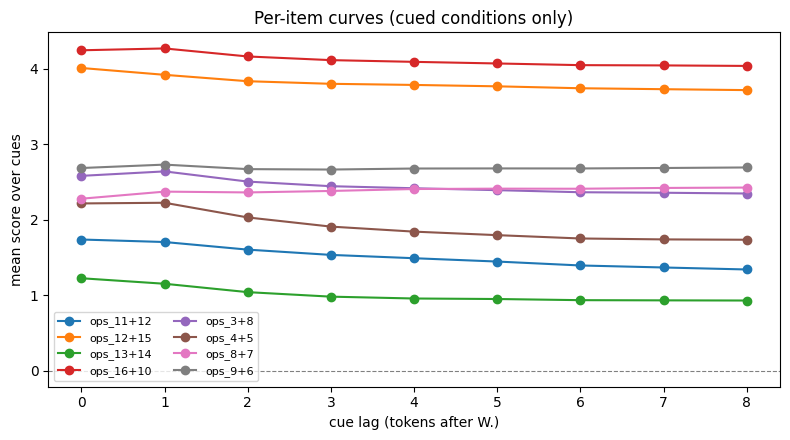

Lag-0 summary:
         condition  mean_score  frac_C
      cue:actually    2.776949     0.0
       cue:hold_on    2.377568     0.0
cue:wait_recompute    2.707782     0.0
            no_cue    1.292883     0.0


In [8]:
cue_df = df[df["condition"] != "no_cue"]

fig, ax = plt.subplots(figsize=(8, 4.5))
for item_name, g in cue_df.groupby("item"):
    gg = (
        g.groupby("lag", as_index=False)["score"].mean()
        .sort_values("lag")
    )
    ax.plot(gg["lag"], gg["score"], marker="o", label=item_name)

ax.axhline(0.0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("cue lag (tokens after W.)")
ax.set_ylabel("mean score over cues")
ax.set_title("Per-item curves (cued conditions only)")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

# Lag-0 snapshot vs no-cue (closest to E0 prompt)
snap = (
    df[df["lag"] == 0]
    .groupby("condition", as_index=False)
    .agg(mean_score=("score", "mean"), frac_C=("top1_is_C", "mean"))
)
print("Lag-0 summary:")
print(snap.to_string(index=False))

## 7. Soft metrics deep dive

Top-1 was saturated (never C under cues), so graded preference is the informative channel.

| Metric | Definition |
|---|---|
| `score` | $\mathrm{logit}(W)-\mathrm{logit}(C)$ — already in `df` |
| `p_C_pair` | softmax over **{W, C} only**: $e^{\ell_C}/(e^{\ell_W}+e^{\ell_C})$ |
| `leans_C` | soft “success”: `score < 0` (prefers C over W, even if top-1 is something else) |
| `delta_score` | cued `score` − length-matched `no_cue` score (same item, lag) |

`p_C_pair` is not the full-vocab probability of C; it only ranks W vs C. That is enough to see whether the cue moves mass toward C.

In [10]:
# Derive soft columns from stored logits (no model re-run)
soft = df.copy()
soft["p_C_pair"] = 1.0 / (1.0 + np.exp(soft["score"]))  # = softmax_C among {W,C}
soft["p_W_pair"] = 1.0 - soft["p_C_pair"]
soft["leans_C"] = soft["score"] < 0

# Pair with no_cue at same (item, lag)
nocue = soft.loc[soft["condition"] == "no_cue", ["item", "lag", "score", "p_C_pair"]].rename(
    columns={"score": "score_nocue", "p_C_pair": "p_C_pair_nocue"}
)
cued = soft[soft["condition"] != "no_cue"].merge(nocue, on=["item", "lag"], how="left")
cued["delta_score"] = cued["score"] - cued["score_nocue"]
cued["delta_p_C"] = cued["p_C_pair"] - cued["p_C_pair_nocue"]

soft_agg = (
    soft.groupby(["condition", "lag"], as_index=False)
    .agg(
        mean_score=("score", "mean"),
        sem_score=("score", "sem"),
        mean_p_C=("p_C_pair", "mean"),
        frac_leans_C=("leans_C", "mean"),
        n=("score", "size"),
    )
)
delta_agg = (
    cued.groupby(["condition", "lag"], as_index=False)
    .agg(
        mean_delta_score=("delta_score", "mean"),
        sem_delta_score=("delta_score", "sem"),
        mean_delta_p_C=("delta_p_C", "mean"),
        frac_delta_neg=("delta_score", lambda s: (s < 0).mean()),  # cue better than no_cue
    )
)

print("Soft aggregate (mean score / p_C_pair / frac score<0):")
print(
    soft_agg.pivot(index="lag", columns="condition", values="mean_p_C")
    .round(3)
    .to_string()
)
print("\nfrac leans_C (score < 0):")
print(
    soft_agg.pivot(index="lag", columns="condition", values="frac_leans_C")
    .round(3)
    .to_string()
)
print("\nmean delta_score (cue − no_cue); negative ⇒ cue helps vs control:")
print(
    delta_agg.pivot(index="lag", columns="condition", values="mean_delta_score")
    .round(3)
    .to_string()
)

Soft aggregate (mean score / p_C_pair / frac score<0):
condition  cue:actually  cue:hold_on  cue:wait_recompute  no_cue
lag                                                             
0                 0.079        0.112               0.088   0.256
1                 0.084        0.109               0.087   0.278
2                 0.090        0.119               0.097   0.296
3                 0.091        0.126               0.104   0.312
4                 0.090        0.131               0.109   0.322
5                 0.090        0.135               0.112   0.329
6                 0.091        0.138               0.114   0.334
7                 0.090        0.138               0.118   0.339
8                 0.091        0.139               0.119   0.340

frac leans_C (score < 0):
condition  cue:actually  cue:hold_on  cue:wait_recompute  no_cue
lag                                                             
0                   0.0          0.0                 0.0   0.000
1       

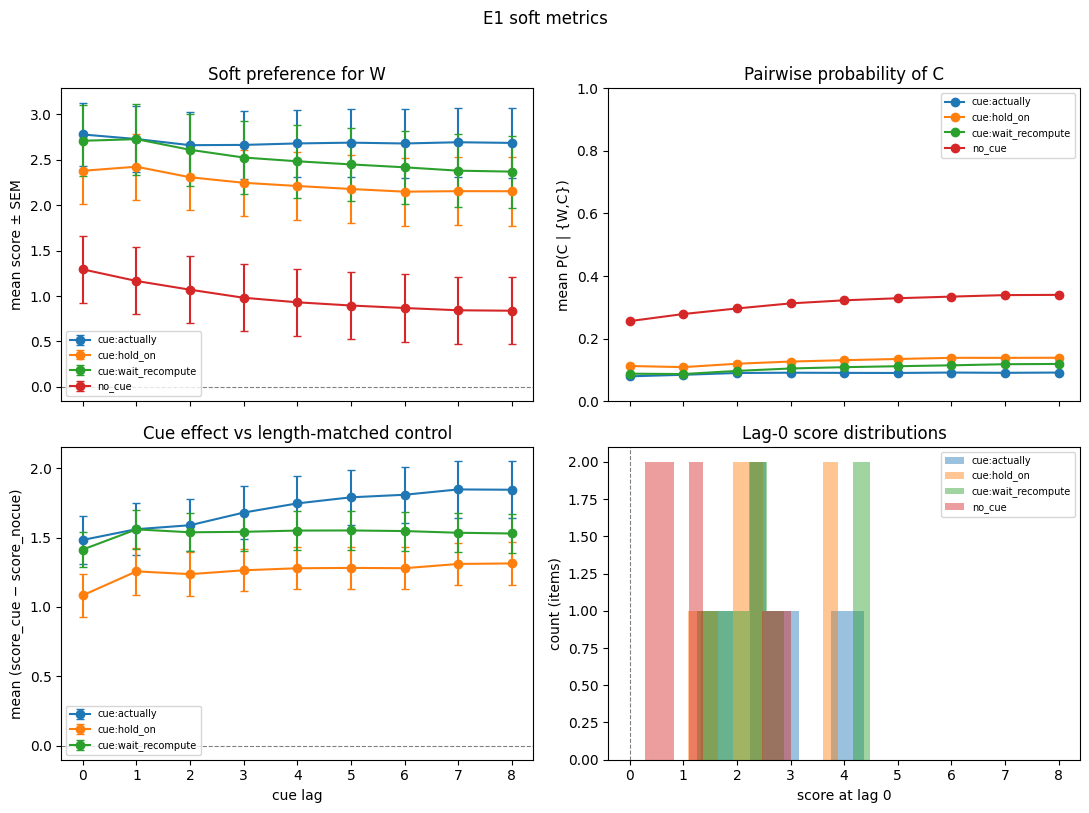

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex="col")

# (0,0) mean score ± SEM
ax = axes[0, 0]
for cond, g in soft_agg.groupby("condition"):
    g = g.sort_values("lag")
    ax.errorbar(g["lag"], g["mean_score"], yerr=g["sem_score"], marker="o", capsize=3, label=cond)
ax.axhline(0.0, color="gray", lw=0.8, ls="--")
ax.set_ylabel("mean score ± SEM")
ax.set_title("Soft preference for W")
ax.legend(fontsize=7)

# (0,1) mean pairwise P(C)
ax = axes[0, 1]
for cond, g in soft_agg.groupby("condition"):
    g = g.sort_values("lag")
    ax.plot(g["lag"], g["mean_p_C"], marker="o", label=cond)
ax.set_ylabel("mean P(C | {W,C})")
ax.set_title("Pairwise probability of C")
ax.set_ylim(0, 1)
ax.legend(fontsize=7)

# (1,0) delta score vs no_cue
ax = axes[1, 0]
for cond, g in delta_agg.groupby("condition"):
    g = g.sort_values("lag")
    ax.errorbar(
        g["lag"], g["mean_delta_score"], yerr=g["sem_delta_score"],
        marker="o", capsize=3, label=cond,
    )
ax.axhline(0.0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("cue lag")
ax.set_ylabel("mean (score_cue − score_nocue)")
ax.set_title("Cue effect vs length-matched control")
ax.legend(fontsize=7)

# (1,1) lag-0 score distributions
ax = axes[1, 1]
lag0 = soft[soft["lag"] == 0]
for cond, g in lag0.groupby("condition"):
    ax.hist(g["score"], bins=10, alpha=0.45, label=cond)
ax.axvline(0.0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("score at lag 0")
ax.set_ylabel("count (items)")
ax.set_title("Lag-0 score distributions")
ax.legend(fontsize=7)

fig.suptitle("E1 soft metrics", y=1.01)
fig.tight_layout()
plt.show()

In [12]:
# Per-item: does lag soften W-preference under the primary cue?
primary = soft[soft["condition"] == "cue:wait_recompute"].copy()
slopes = []
for item_name, g in primary.groupby("item"):
    g = g.sort_values("lag")
    slope = float(np.polyfit(g["lag"], g["score"], 1)[0])
    slopes.append(
        {
            "item": item_name,
            "score_lag0": float(g.loc[g["lag"] == 0, "score"].iloc[0]),
            "score_lag8": float(g.loc[g["lag"] == 8, "score"].iloc[0]),
            "p_C_lag0": float(g.loc[g["lag"] == 0, "p_C_pair"].iloc[0]),
            "p_C_lag8": float(g.loc[g["lag"] == 8, "p_C_pair"].iloc[0]),
            "slope_per_token": slope,
            "leans_C_any_lag": bool(g["leans_C"].any()),
        }
    )
slope_df = pd.DataFrame(slopes).sort_values("slope_per_token")
print("Per-item soft trajectories (cue:wait_recompute):")
print(slope_df.round(3).to_string(index=False))

# Overall cue harm/help
print("\nAcross all cued rows: fraction with delta_score < 0 (cue better than no_cue):")
print(cued.groupby("condition")["delta_score"].apply(lambda s: (s < 0).mean()).round(3).to_string())
print("\nmean delta_score by cue:")
print(cued.groupby("condition")["delta_score"].mean().round(3).to_string())
print(
    f"\nAny cued row with score < 0? {bool((cued['score'] < 0).any())} "
    f"({int((cued['score'] < 0).sum())}/{len(cued)})"
)
print(
    f"Any no_cue row with score < 0? {bool((soft.loc[soft['condition']=='no_cue','score'] < 0).any())} "
    f"({int((soft.loc[soft['condition']=='no_cue','score'] < 0).sum())}/"
    f"{int((soft['condition']=='no_cue').sum())})"
)

Per-item soft trajectories (cue:wait_recompute):
     item  score_lag0  score_lag8  p_C_lag0  p_C_lag8  slope_per_token  leans_C_any_lag
  ops_4+5       2.114       1.442     0.108     0.191           -0.093            False
ops_11+12       1.869       1.391     0.134     0.199           -0.066            False
ops_12+15       4.194       3.743     0.015     0.023           -0.056            False
ops_16+10       4.489       4.109     0.011     0.016           -0.055            False
  ops_3+8       2.520       2.196     0.074     0.100           -0.050            False
ops_13+14       1.263       0.973     0.220     0.274           -0.037            False
  ops_9+6       2.768       2.678     0.059     0.064           -0.015            False
  ops_8+7       2.444       2.417     0.080     0.082           -0.009            False

Across all cued rows: fraction with delta_score < 0 (cue better than no_cue):
condition
cue:actually          0.0
cue:hold_on           0.0
cue:wait_recompute

## 8. Verdict cell

Fill after running. Suggested checks:

**Hard (top-1)**
1. Do cued conditions ever flip top-1 to C?
2. How does that compare to `no_cue`?

**Soft (score / pairwise P(C))**
3. Do cues lower `score` relative to `no_cue` (`delta_score < 0`), or raise it?
4. Does mean score or `p_C_pair` move with lag (even if top-1 is flat)?
5. Does any item ever `leans_C` (`score < 0`) under a cue?

**If top-1 saturated but soft metrics move:** report the graded curve; that is the behavioral baseline for E2+.

**If soft metrics also show cues ≥ no_cue (more W-preferring):** revision language is not helping in this domain — structural claims must beat a near-null behavioral effect.

In [13]:
# Quick automatic summary to seed the verdict (hard + soft)
pivot = agg.pivot(index="lag", columns="condition", values="mean_score")
print("mean score by lag × condition:")
print(pivot.round(3).to_string())

print("\nfrac top-1=C by lag × condition:")
pivot_c = agg.pivot(index="lag", columns="condition", values="frac_top1_C")
print(pivot_c.round(3).to_string())

sub = soft_agg[soft_agg["condition"] == "cue:wait_recompute"].sort_values("lag")
if len(sub) >= 2:
    slope = np.polyfit(sub["lag"], sub["mean_score"], 1)[0]
    slope_p = np.polyfit(sub["lag"], sub["mean_p_C"], 1)[0]
    print(f"\nLinear slope mean_score vs lag (wait_recompute): {slope:+.4f} per token")
    print(f"Linear slope mean_p_C_pair vs lag (wait_recompute): {slope_p:+.4f} per token")

print("\nLag-0 soft snapshot:")
lag0_soft = (
    soft[soft["lag"] == 0]
    .groupby("condition", as_index=False)
    .agg(
        mean_score=("score", "mean"),
        mean_p_C=("p_C_pair", "mean"),
        frac_leans_C=("leans_C", "mean"),
        frac_top1_C=("top1_is_C", "mean"),
    )
)
print(lag0_soft.round(3).to_string(index=False))

print(
    "\nInterpretation aid:\n"
    "  positive score = prefers W; higher p_C_pair = more soft mass on C;\n"
    "  delta_score < 0 means cue helps vs no_cue; top-1=C is hard revision success."
)

mean score by lag × condition:
condition  cue:actually  cue:hold_on  cue:wait_recompute  no_cue
lag                                                             
0                 2.777        2.378               2.708   1.293
1                 2.727        2.422               2.726   1.165
2                 2.659        2.306               2.608   1.069
3                 2.662        2.246               2.523   0.981
4                 2.679        2.210               2.482   0.931
5                 2.687        2.177               2.448   0.895
6                 2.678        2.148               2.416   0.868
7                 2.692        2.154               2.379   0.843
8                 2.684        2.152               2.369   0.838

frac top-1=C by lag × condition:
condition  cue:actually  cue:hold_on  cue:wait_recompute  no_cue
lag                                                             
0                   0.0          0.0                 0.0   0.000
1                   0.0  

## 9. Design B — wrong-trajectory depth

Design A varied **filler lag** after `W`. Design B varies how much **wrong commitment text** appears before the cue.

```text
{a} + {b} = {W}.{WRONG_STEPS × depth}{CUE} {a} + {b} =
```

Each step restates/reinforces `W` (e.g. ` Yes, 25.`, ` So the sum is 25.`, …). Depth 0 = cue right after `W.` (same as A lag 0).

**Three conditions at each depth** (to separate content from length):

| Condition | Middle |
|---|---|
| `wrong+cue` | wrong steps + revision cue |
| `wrong+no_cue` | wrong steps + filler matched to cue length |
| `filler+cue` | ` ...` filler matched to wrong-steps length + cue |

If `wrong+cue` is more W-preferring than `filler+cue` at the same length, wrong *content* matters beyond token count.

In [14]:
DEPTHS_B = list(range(0, 9))  # 0..8 wrong commitment steps


def wrong_step_templates(W_str: str) -> list[str]:
    """Scripted wrong-commitment clauses; each restates W as a single token."""
    return [
        f" Yes,{W_str}.",
        f" So the sum is{W_str}.",
        f" That means{W_str} is correct.",
        f" Therefore{W_str}.",
        f" Final answer:{W_str}.",
        f" Confirmed:{W_str}.",
        f" We obtained{W_str}.",
        f" Result equals{W_str}.",
    ]


def wrong_span(item: Item, depth: int) -> str:
    if depth <= 0:
        return ""
    steps = wrong_step_templates(item.W_str)
    if depth > len(steps):
        raise ValueError(f"depth={depth} > available steps={len(steps)}")
    return "".join(steps[:depth])


def build_prompt_B(item: Item, depth: int, condition: str) -> str:
    """condition in {'wrong+cue', 'wrong+no_cue', 'filler+cue'}."""
    prefix = f"{item.a} + {item.b} ={item.W_str}."
    suffix = f" {item.a} + {item.b} ="
    cue = CUES["wait_recompute"]
    cue_len = n_tokens(cue)
    wrong = wrong_span(item, depth)
    wrong_len = n_tokens(wrong) if wrong else 0

    if condition == "wrong+cue":
        middle = wrong + cue
    elif condition == "wrong+no_cue":
        middle = wrong + filler_span(cue_len)
    elif condition == "filler+cue":
        middle = filler_span(wrong_len) + cue
    else:
        raise ValueError(condition)
    return prefix + middle + suffix


# Sanity: depth progression + length matching
it0 = ITEMS[0]
print("Wrong steps for", it0.name)
for d in range(0, 5):
    span = wrong_span(it0, d)
    print(f"  depth {d}: {span!r}  ({n_tokens(span)} toks)")

print("\nLength checks (content tokens):")
for d in [0, 1, 4, 8]:
    p_wc = build_prompt_B(it0, d, "wrong+cue")
    p_wn = build_prompt_B(it0, d, "wrong+no_cue")
    p_fc = build_prompt_B(it0, d, "filler+cue")
    print(
        f"  d={d}: wrong+cue={n_tokens(p_wc)}  wrong+no_cue={n_tokens(p_wn)}  "
        f"filler+cue={n_tokens(p_fc)}"
    )
    assert n_tokens(p_wc) == n_tokens(p_wn), "cue length match failed"
    assert n_tokens(p_wc) == n_tokens(p_fc), "wrong-span length match failed"
print("OK")
print("\nExample depth=3 wrong+cue:\n", build_prompt_B(it0, 3, "wrong+cue"))
print("tokens:", model.to_str_tokens(build_prompt_B(it0, 3, "wrong+cue")))

Wrong steps for ops_12+15
  depth 0: ''  (0 toks)
  depth 1: ' Yes, 25.'  (4 toks)
  depth 2: ' Yes, 25. So the sum is 25.'  (10 toks)
  depth 3: ' Yes, 25. So the sum is 25. That means 25 is correct.'  (16 toks)
  depth 4: ' Yes, 25. So the sum is 25. That means 25 is correct. Therefore 25.'  (19 toks)

Length checks (content tokens):
  d=0: wrong+cue=17  wrong+no_cue=17  filler+cue=17
  d=1: wrong+cue=21  wrong+no_cue=21  filler+cue=21
  d=4: wrong+cue=36  wrong+no_cue=36  filler+cue=36
  d=8: wrong+cue=54  wrong+no_cue=54  filler+cue=54
OK

Example depth=3 wrong+cue:
 12 + 15 = 25. Yes, 25. So the sum is 25. That means 25 is correct. Wait, let me recompute. 12 + 15 =
tokens: ['<|endoftext|>', '12', ' +', ' 15', ' =', ' 25', '.', ' Yes', ',', ' 25', '.', ' So', ' the', ' sum', ' is', ' 25', '.', ' That', ' means', ' 25', ' is', ' correct', '.', ' Wait', ',', ' let', ' me', ' recomp', 'ute', '.', ' 12', ' +', ' 15', ' =']


In [15]:
rows_B = []
conds_B = ["wrong+cue", "wrong+no_cue", "filler+cue"]
total_B = len(ITEMS) * len(conds_B) * len(DEPTHS_B)
done_B = 0

for item in ITEMS:
    for cond in conds_B:
        for depth in DEPTHS_B:
            prompt = build_prompt_B(item, depth, cond)
            out = score_prompt(prompt, item.W_str, item.C_str)
            rows_B.append(
                {
                    "item": item.name,
                    "condition": cond,
                    "depth": depth,
                    "design": "B",
                    **{k: out[k] for k in (
                        "n_tokens", "t_star", "score", "top1",
                        "top1_is_W", "top1_is_C", "logit_W", "logit_C",
                    )},
                }
            )
            done_B += 1
            if done_B % 36 == 0 or done_B == total_B:
                print(f"{done_B}/{total_B}")

df_B = pd.DataFrame(rows_B)
df_B["p_C_pair"] = 1.0 / (1.0 + np.exp(df_B["score"]))
df_B["leans_C"] = df_B["score"] < 0
print(df_B.shape)
df_B.head(9)

36/216
72/216
108/216
144/216
180/216
216/216
(216, 14)


,item,condition,depth,design,n_tokens,t_star,score,top1,top1_is_W,top1_is_C,logit_W,logit_C,p_C_pair,leans_C
0,ops_12+15,wrong+cue,0,B,17,17,4.194225,25,True,False,17.344603,13.150377,0.014858,False
1,ops_12+15,wrong+cue,1,B,21,21,3.732028,25,True,False,17.585157,13.853129,0.023384,False
2,ops_12+15,wrong+cue,2,B,27,27,3.797177,25,True,False,17.500845,13.703668,0.021942,False
3,ops_12+15,wrong+cue,3,B,33,33,3.677227,25,True,False,17.616444,13.939217,0.024669,False
4,ops_12+15,wrong+cue,4,B,36,36,3.830762,25,True,False,17.780060,13.949298,0.021232,False
5,ops_12+15,wrong+cue,5,B,41,41,3.763721,25,True,False,17.859558,14.095838,0.022671,False
6,ops_12+15,wrong+cue,6,B,46,46,3.798218,25,True,False,18.070395,14.272177,0.021919,False
7,ops_12+15,wrong+cue,7,B,50,50,4.026221,25,True,False,18.163809,14.137588,0.017529,False
8,ops_12+15,wrong+cue,8,B,54,54,4.099495,25,True,False,18.093224,13.993729,0.016311,False


In [16]:
agg_B = (
    df_B.groupby(["condition", "depth"], as_index=False)
    .agg(
        mean_score=("score", "mean"),
        sem_score=("score", "sem"),
        mean_p_C=("p_C_pair", "mean"),
        frac_top1_C=("top1_is_C", "mean"),
        frac_leans_C=("leans_C", "mean"),
        n=("score", "size"),
    )
)

# Deltas vs filler+cue and vs wrong+no_cue (same depth, item)
base_fill = df_B.loc[df_B["condition"] == "filler+cue", ["item", "depth", "score", "p_C_pair"]].rename(
    columns={"score": "score_filler_cue", "p_C_pair": "p_C_filler_cue"}
)
base_wn = df_B.loc[df_B["condition"] == "wrong+no_cue", ["item", "depth", "score", "p_C_pair"]].rename(
    columns={"score": "score_wrong_nocue", "p_C_pair": "p_C_wrong_nocue"}
)
wc = df_B[df_B["condition"] == "wrong+cue"].merge(base_fill, on=["item", "depth"]).merge(
    base_wn, on=["item", "depth"]
)
wc["delta_vs_filler_cue"] = wc["score"] - wc["score_filler_cue"]  # >0 ⇒ wrong content hurts more than length
wc["delta_vs_wrong_nocue"] = wc["score"] - wc["score_wrong_nocue"]  # >0 ⇒ cue hurts vs filler after wrong steps

delta_B = (
    wc.groupby("depth", as_index=False)
    .agg(
        mean_delta_vs_filler=("delta_vs_filler_cue", "mean"),
        sem_delta_vs_filler=("delta_vs_filler_cue", "sem"),
        mean_delta_vs_nocue=("delta_vs_wrong_nocue", "mean"),
        sem_delta_vs_nocue=("delta_vs_wrong_nocue", "sem"),
        frac_worse_than_filler=("delta_vs_filler_cue", lambda s: (s > 0).mean()),
    )
)

print("mean score by depth × condition:")
print(agg_B.pivot(index="depth", columns="condition", values="mean_score").round(3).to_string())
print("\nmean p_C_pair:")
print(agg_B.pivot(index="depth", columns="condition", values="mean_p_C").round(3).to_string())
print("\nfrac top-1=C:")
print(agg_B.pivot(index="depth", columns="condition", values="frac_top1_C").round(3).to_string())
print("\nfrac leans_C (score<0):")
print(agg_B.pivot(index="depth", columns="condition", values="frac_leans_C").round(3).to_string())
print("\nwrong+cue deltas:")
print(delta_B.round(3).to_string(index=False))

mean score by depth × condition:
condition  filler+cue  wrong+cue  wrong+no_cue
depth                                         
0               2.708      2.708         1.293
1               2.482      2.136         1.227
2               2.346      2.130         1.773
3               2.400      2.030         1.716
4               2.449      2.036         1.894
5               2.545      1.920         1.847
6               2.625      1.956         1.744
7               2.688      2.140         2.058
8               2.722      2.217         2.135

mean p_C_pair:
condition  filler+cue  wrong+cue  wrong+no_cue
depth                                         
0               0.088      0.088         0.256
1               0.109      0.143         0.272
2               0.121      0.151         0.194
3               0.117      0.168         0.205
4               0.113      0.170         0.183
5               0.105      0.179         0.186
6               0.098      0.175         0.203
7          

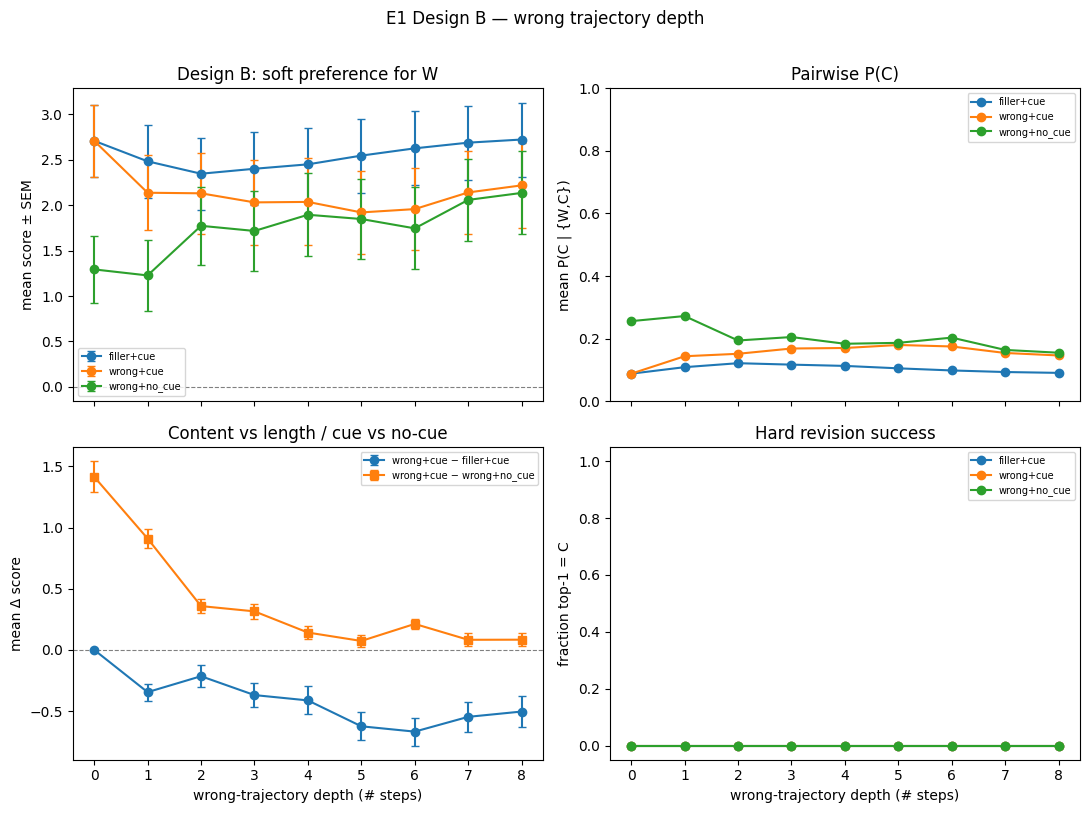

Per-item score slope vs depth (wrong+cue):
     item  score_d0  score_d8  slope_per_step  leans_C_any  top1_C_any
ops_11+12     1.869     0.687          -0.106        False       False
  ops_4+5     2.114     1.160          -0.080        False       False
  ops_9+6     2.768     2.106          -0.066        False       False
ops_16+10     4.489     4.104          -0.043        False       False
ops_13+14     1.263     0.993          -0.034        False       False
  ops_3+8     2.520     2.259          -0.005        False       False
  ops_8+7     2.444     2.331           0.004        False       False
ops_12+15     4.194     4.099           0.010        False       False

Aggregate slope score vs depth (wrong+cue): -0.0402 per step
Mean delta wrong+cue − filler+cue over depths: -0.410 (frac>0: 0.07)
Mean delta wrong+cue − wrong+no_cue over depths: +0.399 (frac>0: 0.86)


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex="col")

ax = axes[0, 0]
for cond, g in agg_B.groupby("condition"):
    g = g.sort_values("depth")
    ax.errorbar(g["depth"], g["mean_score"], yerr=g["sem_score"], marker="o", capsize=3, label=cond)
ax.axhline(0.0, color="gray", lw=0.8, ls="--")
ax.set_ylabel("mean score ± SEM")
ax.set_title("Design B: soft preference for W")
ax.legend(fontsize=7)

ax = axes[0, 1]
for cond, g in agg_B.groupby("condition"):
    g = g.sort_values("depth")
    ax.plot(g["depth"], g["mean_p_C"], marker="o", label=cond)
ax.set_ylabel("mean P(C | {W,C})")
ax.set_ylim(0, 1)
ax.set_title("Pairwise P(C)")
ax.legend(fontsize=7)

ax = axes[1, 0]
g = delta_B.sort_values("depth")
ax.errorbar(
    g["depth"], g["mean_delta_vs_filler"], yerr=g["sem_delta_vs_filler"],
    marker="o", capsize=3, label="wrong+cue − filler+cue",
)
ax.errorbar(
    g["depth"], g["mean_delta_vs_nocue"], yerr=g["sem_delta_vs_nocue"],
    marker="s", capsize=3, label="wrong+cue − wrong+no_cue",
)
ax.axhline(0.0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("wrong-trajectory depth (# steps)")
ax.set_ylabel("mean Δ score")
ax.set_title("Content vs length / cue vs no-cue")
ax.legend(fontsize=7)

ax = axes[1, 1]
for cond, g in agg_B.groupby("condition"):
    g = g.sort_values("depth")
    ax.plot(g["depth"], g["frac_top1_C"], marker="o", label=cond)
ax.set_xlabel("wrong-trajectory depth (# steps)")
ax.set_ylabel("fraction top-1 = C")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Hard revision success")
ax.legend(fontsize=7)

fig.suptitle("E1 Design B — wrong trajectory depth", y=1.01)
fig.tight_layout()
plt.show()

# Per-item slopes under wrong+cue
print("Per-item score slope vs depth (wrong+cue):")
slope_rows = []
for item_name, g in df_B[df_B["condition"] == "wrong+cue"].groupby("item"):
    g = g.sort_values("depth")
    slope = float(np.polyfit(g["depth"], g["score"], 1)[0])
    slope_rows.append(
        {
            "item": item_name,
            "score_d0": float(g.loc[g["depth"] == 0, "score"].iloc[0]),
            "score_d8": float(g.loc[g["depth"] == 8, "score"].iloc[0]),
            "slope_per_step": slope,
            "leans_C_any": bool(g["leans_C"].any()),
            "top1_C_any": bool(g["top1_is_C"].any()),
        }
    )
print(pd.DataFrame(slope_rows).sort_values("slope_per_step").round(3).to_string(index=False))

sub = agg_B[agg_B["condition"] == "wrong+cue"].sort_values("depth")
print(
    f"\nAggregate slope score vs depth (wrong+cue): "
    f"{np.polyfit(sub['depth'], sub['mean_score'], 1)[0]:+.4f} per step"
)
print(
    f"Mean delta wrong+cue − filler+cue over depths: "
    f"{wc['delta_vs_filler_cue'].mean():+.3f} "
    f"(frac>0: {(wc['delta_vs_filler_cue'] > 0).mean():.2f})"
)
print(
    f"Mean delta wrong+cue − wrong+no_cue over depths: "
    f"{wc['delta_vs_wrong_nocue'].mean():+.3f} "
    f"(frac>0: {(wc['delta_vs_wrong_nocue'] > 0).mean():.2f})"
)

## 10. Design B verdict notes

- **Depth effect:** does `wrong+cue` score rise with more wrong steps (harder revision)?
- **Content vs length:** is `wrong+cue` systematically above `filler+cue`?
- **Cue effect after wrong steps:** is `wrong+cue` above `wrong+no_cue` (cue still hurts / fails)?
- Compare to Design A: A said filler lag softens slightly and cues hurt; B asks whether *wrong prose* does something filler does not.